In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, roc_auc_score
)
import seaborn as sns
import warnings
import tqdm as tqdm
warnings.filterwarnings("ignore")

In [2]:
CONFIG = {
    "data_dir"   : "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray",
    "img_size"   : 224,
    "batch_size" : 32,
    "num_epochs" : 15,
    "lr"         : 1e-3,
    "num_workers": 2,
    "checkpoint" : "best_xray_model.pth",
    "seed"       : 42,
    "threshold"  : 0.5,
}

torch.manual_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


CLASSES     = ["NORMAL", "PNEUMONIA"]
NUM_CLASSES = 2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Device: cuda


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),                
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
 
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [4]:
def make_weighted_sampler(dataset):

    labels = [label for _, label in dataset.samples]
    class_counts = np.bincount(labels)

    print("Classes found:", dataset.classes)
    print("Class counts:", class_counts)

    if len(class_counts) < 2:
        raise ValueError(
            "Dataset contains fewer than 2 classes. "
            "Check your train directory structure."
        )

    class_weights = 1.0 / class_counts

    sample_weights = [
        class_weights[label]
        for _, label in dataset.samples
    ]

    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(dataset),
        replacement=True
    )

    return sampler

In [5]:
def get_loaders():
    train_dataset = datasets.ImageFolder(
        os.path.join(CONFIG["data_dir"], "train"),
        transform=train_transforms
    )
    val_dataset = datasets.ImageFolder(
        os.path.join(CONFIG["data_dir"], "val"),
        transform=val_transforms
    )
    test_dataset = datasets.ImageFolder(
        os.path.join(CONFIG["data_dir"], "test"),
        transform=val_transforms
    )
 
    #weighted sampler is only for training
    sampler = make_weighted_sampler(train_dataset)
 
    # When using a sampler, shuffle must be False (sampler handles order)
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        sampler=sampler,     
        num_workers=CONFIG["num_workers"],
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=CONFIG["batch_size"],
        shuffle=False, num_workers=CONFIG["num_workers"]
    )
    test_loader = DataLoader(
        test_dataset, batch_size=CONFIG["batch_size"],
        shuffle=False, num_workers=CONFIG["num_workers"]
    )
 
    print(f"Train: {len(train_dataset)} | "
          f"Val: {len(val_dataset)} | Test: {len(test_dataset)}")
    return train_loader, val_loader, test_loader

In [6]:
# MODEL: ResNet-50 with partial fine-tuning
def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad=True


#Replacing Head for Binary classification:
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, NUM_CLASSES)
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"\nTrainable: {trainable:,} / {total:,} params")
    return model



In [7]:
def train(model, train_loader, val_loader,
          start_epoch=1, best_val_acc=0.0, resume_optimizer=None):
 
    criterion = nn.CrossEntropyLoss()
 
    if resume_optimizer is not None:
        optimizer = resume_optimizer
    else:
        # Differential learning rates (Phase 3 technique)
        layer4_params = list(model.layer4.parameters())
        head_params   = list(model.fc.parameters())
        optimizer = optim.Adam([
            {"params": layer4_params, "lr": 1e-4},
            {"params": head_params,   "lr": 1e-3},
        ], weight_decay=1e-4)
 
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["num_epochs"]
    )
 
    history = {k: [] for k in ["train_loss", "train_acc",
                                "val_loss",   "val_acc"]}

    for epoch in range(start_epoch, CONFIG["num_epochs"] + 1):
        start = time.time()
 
        # --- Train ---
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for images, labels in tqdm.tqdm(train_loader, desc="Training..."):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
 
            t_loss    += loss.item()
            t_correct += (outputs.argmax(1) == labels).sum().item()
            t_total   += labels.size(0)
 
        # Validate 
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm.tqdm(val_loader, desc="Evaluating.."):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                v_loss    += loss.item()
                v_correct += (outputs.argmax(1) == labels).sum().item()
                v_total   += labels.size(0)
 
        tl = t_loss / len(train_loader)
        ta = 100.0 * t_correct / t_total
        vl = v_loss / len(val_loader)
        va = 100.0 * v_correct / v_total
 
        for k, v in zip(history, [tl, ta, vl, va]):
            history[k].append(v)
 
        scheduler.step()
        elapsed = time.time() - start
 
        print(f"Epoch [{epoch:2d}/{CONFIG['num_epochs']}] "
              f"Train {ta:.2f}% | Val {va:.2f}% | "
              f"Loss {tl:.4f}/{vl:.4f} | {elapsed:.1f}s")
 
        if va > best_val_acc:
            best_val_acc = va
            torch.save({
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "val_acc"    : va,
                "val_loss"   : vl,
            }, CONFIG["checkpoint"])
            print(f"  ✓ Best val acc: {va:.2f}% → saved")
 
    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
    return history

In [8]:
def clinical_evaluation(model, test_loader, threshold=0.5):
    """
    Full clinical metric report on the test set.
    threshold: probability cutoff for PNEUMONIA prediction.
               lower threshold = more sensitive (catches more sick)
               higher threshold = more specific (fewer false alarms)
    """
    model.eval()
    all_probs  = []   
    all_preds  = []   
    all_labels = []
 
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)[:, 1]  # P(PNEUMONIA)
            preds = (probs >= threshold).long()
 
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
 
    all_probs  = np.array(all_probs)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
 
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    TN, FP, FN, TP = cm.ravel()
 
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0
    f1          = 2 * precision * sensitivity / (precision + sensitivity + 1e-8)
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    auc_score   = roc_auc_score(all_labels, all_probs)
 
    
    print(f"  CLINICAL EVALUATION REPORT  (threshold={threshold})")
  
    print(f"  Accuracy    : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Sensitivity : {sensitivity:.4f}  ← catches sick patients")
    print(f"  Specificity : {specificity:.4f}  ← avoids false alarms")
    print(f"  Precision   : {precision:.4f}")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"  AUC-ROC     : {auc_score:.4f}")
    print(f"\n  Confusion matrix:")
    print(f"    TN={TN}  FP={FP}")
    print(f"    FN={FN}  TP={TP}")
    print(f"\n  Missed sick patients (FN): {FN}")
    print(f"  False alarms (FP)        : {FP}")
   
 
    return all_probs, all_labels, {
        "sensitivity": sensitivity, "specificity": specificity,
        "precision"  : precision,   "f1"         : f1,
        "accuracy"   : accuracy,    "auc"        : auc_score
    }
 
 

In [9]:
def plot_roc_curve(all_probs, all_labels, metrics):
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='#534AB7', lw=2,
            label=f"ResNet-50 (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label="Random classifier (AUC=0.5)")
 
    # Mark the operating point at current threshold
    current_tpr = metrics["sensitivity"]
    current_fpr = 1 - metrics["specificity"]
    ax.scatter(current_fpr, current_tpr, s=120, color='red', zorder=5,
               label=f"Current threshold={CONFIG['threshold']}")
 
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=11)
    ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
    ax.set_title("ROC Curve — Pneumonia Classifier", fontsize=13)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150)
    plt.show()
    print(f"ROC curve saved. AUC = {roc_auc:.4f}")
    return fpr, tpr, thresholds
 

In [10]:
def tune_threshold(fpr, tpr, thresholds, all_probs, all_labels):
    youden_scores = tpr - fpr   # sensitivity + specificity - 1
    best_idx      = np.argmax(youden_scores)
    best_threshold = thresholds[best_idx]
 
    print(f"\nThreshold analysis:")
    print(f"  Default threshold (0.5) metrics already reported above.")
    print(f"  Optimal threshold (Youden): {best_threshold:.3f}")
 
    # Re-evaluate at optimal threshold
    print(f"\nRe-evaluating at optimal threshold {best_threshold:.3f}...")
    _, _, new_metrics = clinical_evaluation(
        model_global, test_loader_global,
        threshold=best_threshold
    )
 
    # Plot sensitivity vs specificity across thresholds
    all_thresh = np.linspace(0.1, 0.9, 50)
    sensitivities, specificities = [], []
 
    for t in all_thresh:
        preds = (all_probs >= t).astype(int)
        cm = confusion_matrix(all_labels, preds)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivities.append(tp / (tp + fn + 1e-8))
            specificities.append(tn / (tn + fp + 1e-8))
        else:
            sensitivities.append(0)
            specificities.append(0)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(all_thresh, sensitivities, ms=4, label="Sensitivity (recall)")
    ax.plot(all_thresh, specificities,ms=4, label="Specificity")
    ax.axvline(best_threshold, color='green', linestyle='--',
               label=f"Optimal: {best_threshold:.2f}")
    ax.axvline(0.5, color='gray', linestyle=':', label="Default: 0.50")
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_title("Sensitivity vs Specificity across thresholds")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
 
    return best_threshold

In [11]:
def plot_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    labels = ["NORMAL", "PNEUMONIA"]
 
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=1, annot_kws={"size": 14})
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title("Confusion Matrix — Test Set", fontsize=13)
    plt.tight_layout()
    plt.show()

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
 
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
 
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
 
    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.to(device).requires_grad_(True)
        output = self.model(image_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        # Confidence for the predicted class
        confidence = F.softmax(output, dim=1)[0, class_idx].item()
        return cam, class_idx, confidence
 
    @staticmethod
    def overlay(image_tensor, cam, alpha=0.45):
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        img  = (image_tensor.squeeze().cpu() * std + mean).clamp(0,1)
        img  = img.permute(1,2,0).numpy()
        cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
        heatmap = cv2.applyColorMap(
            (cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET
        )
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        return np.clip(alpha * heatmap + (1 - alpha) * img, 0, 1), img
 
 
def visualize_gradcam_xray(model, test_loader, n_samples=6):
    """
    Show n_samples X-rays with Grad-CAM overlay.
    Deliberately picks both correct AND wrong predictions
    so I can see what the model gets right and wrong.
    """
    gradcam = GradCAM(model, model.layer4[-1])
 
    all_images, all_labels = [], []
    for images, labels in test_loader:
        all_images.append(images)
        all_labels.append(labels)
        if len(torch.cat(all_images)) >= 64:
            break
    all_images = torch.cat(all_images)[:64]
    all_labels = torch.cat(all_labels)[:64]
 
    # Get predictions for all
    model.eval()
    with torch.no_grad():
        outputs = model(all_images.to(device))
        probs   = F.softmax(outputs, dim=1)[:, 1].cpu()
        preds   = (probs >= CONFIG["threshold"]).long()
 
    # Find correct and wrong predictions
    correct_idx = (preds == all_labels).nonzero(as_tuple=True)[0]
    wrong_idx   = (preds != all_labels).nonzero(as_tuple=True)[0]
 
    # Take half correct, half wrong (up to n_samples total)
    n_correct = min(n_samples // 2, len(correct_idx))
    n_wrong   = min(n_samples - n_correct, len(wrong_idx))
    selected  = torch.cat([correct_idx[:n_correct], wrong_idx[:n_wrong]])
 
    fig, axes = plt.subplots(2, len(selected), figsize=(3.5 * len(selected), 7))
    fig.suptitle(
        "Grad-CAM on Chest X-rays\n"
        "Top: original | Bottom: where model looked\n"
        "Green title = correct | Red title = wrong",
        fontsize=10
    )
 
    for col, idx in enumerate(selected):
        img_tensor = all_images[idx].unsqueeze(0)
        true_label = all_labels[idx].item()
        cam, pred_idx, confidence = gradcam.generate(img_tensor)
        overlay, orig = GradCAM.overlay(img_tensor, cam)
 
        color    = "green" if pred_idx == true_label else "red"
        true_str = CLASSES[true_label]
        pred_str = CLASSES[pred_idx]
 
        axes[0, col].imshow(orig, cmap='gray' if orig.shape[2] == 1 else None)
        axes[0, col].set_title(f"True: {true_str}", fontsize=8)
        axes[0, col].axis("off")
 
        axes[1, col].imshow(overlay)
        axes[1, col].set_title(
            f"Pred: {pred_str}\nConf: {confidence:.2f}",
            fontsize=8, color=color
        )
        axes[1, col].axis("off")
 
    plt.tight_layout()
    plt.show()

 
 
 
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],  label="Val")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"], label="Val")
    ax2.set_title("Accuracy (%)"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()
 
 

Classes found: ['NORMAL', 'PNEUMONIA']
Class counts: [1341 3875]
Train: 5216 | Val: 16 | Test: 624
Training from scratch...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s] 



Trainable: 15,489,794 / 24,033,090 params


Evaluating..: 100%|██████████| 1/1 [00:00<00:00,  1.83it/s]


Epoch [ 1/15] Train 91.79% | Val 87.50% | Loss 0.2036/0.2135 | 77.3s
  ✓ Best val acc: 87.50% → saved


...

Epoch [13/15] Train 98.77% | Val 93.75% | Loss 0.0347/0.1145 | 65.6s


Evaluating..: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]


Epoch [14/15] Train 98.47% | Val 93.75% | Loss 0.0414/0.1457 | 65.0s


Evaluating..: 100%|██████████| 1/1 [00:00<00:00,  2.39it/s]


Epoch [15/15] Train 98.70% | Val 93.75% | Loss 0.0355/0.0980 | 69.0s

Best validation accuracy: 100.00%


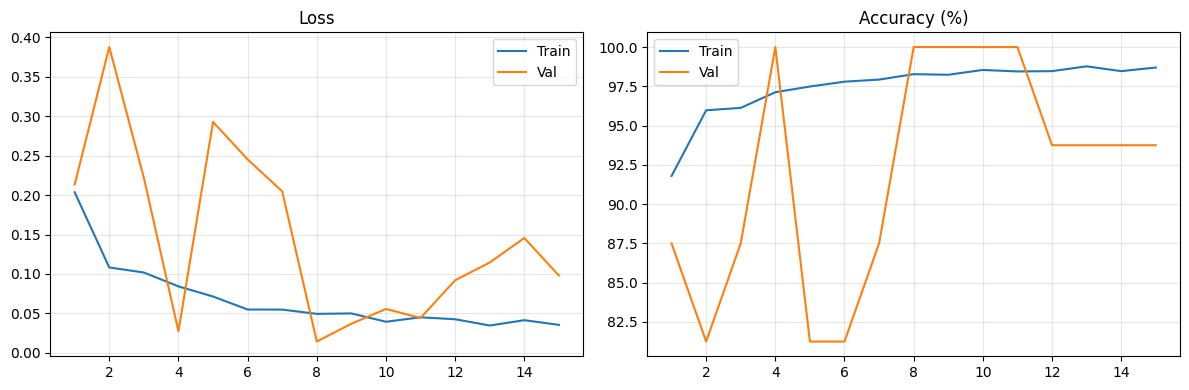

  CLINICAL EVALUATION REPORT  (threshold=0.5)
  Accuracy    : 0.9327  (93.27%)
  Sensitivity : 0.9538  ← catches sick patients
  Specificity : 0.8974  ← avoids false alarms
  Precision   : 0.9394
  F1-Score    : 0.9466
  AUC-ROC     : 0.9791

  Confusion matrix:
    TN=210  FP=24
    FN=18  TP=372

  Missed sick patients (FN): 18
  False alarms (FP)        : 24


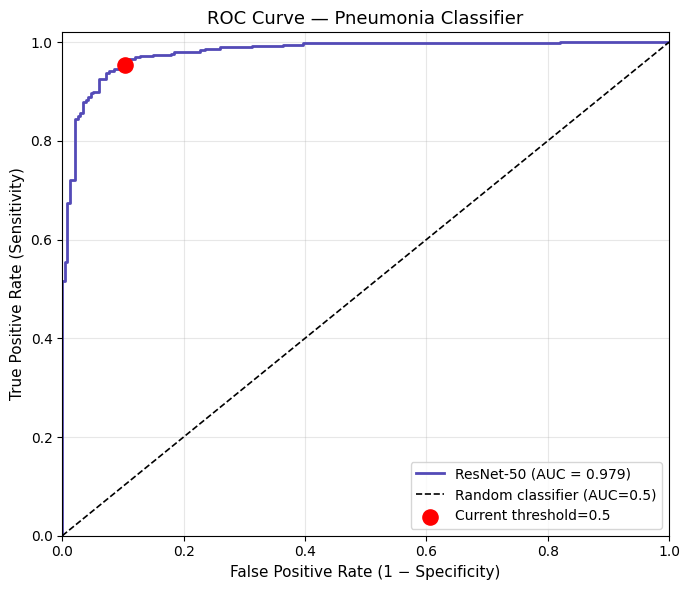

ROC curve saved. AUC = 0.9791

Threshold analysis:
  Default threshold (0.5) metrics already reported above.
  Optimal threshold (Youden): 0.785

Re-evaluating at optimal threshold 0.785...
  CLINICAL EVALUATION REPORT  (threshold=0.7852949500083923)
  Accuracy    : 0.9311  (93.11%)
  Sensitivity : 0.9256  ← catches sick patients
  Specificity : 0.9402  ← avoids false alarms
  Precision   : 0.9627
  F1-Score    : 0.9438
  AUC-ROC     : 0.9791

  Confusion matrix:
    TN=220  FP=14
    FN=29  TP=361

  Missed sick patients (FN): 29
  False alarms (FP)        : 14


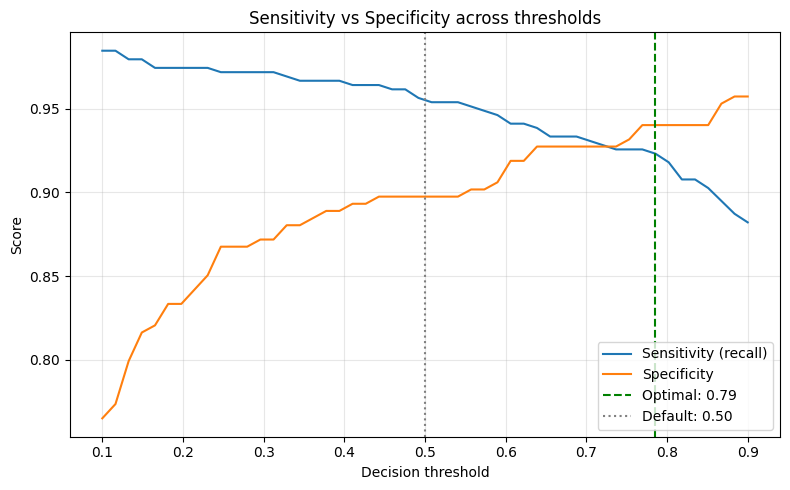

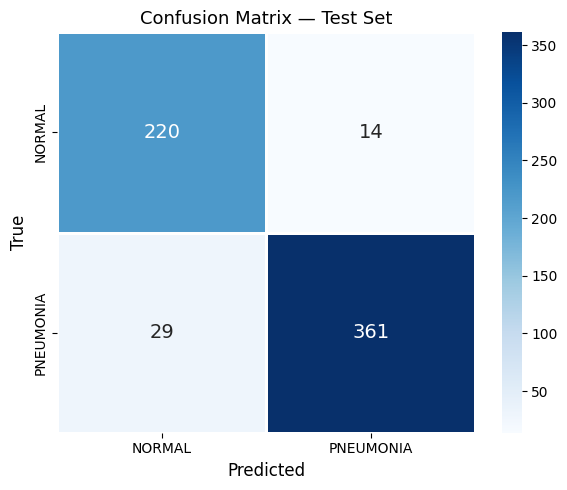

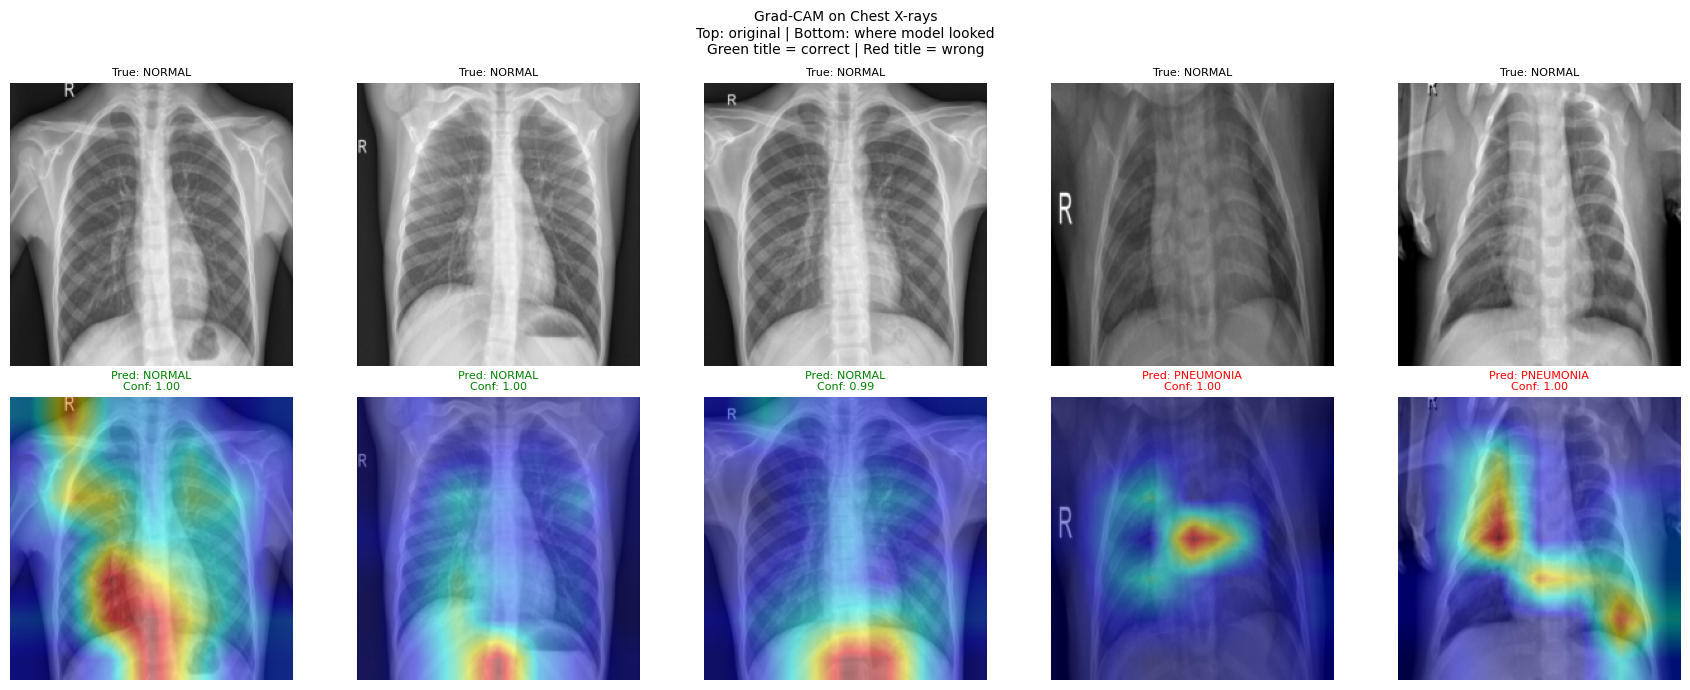

In [13]:
model_global      = None
test_loader_global = None
 
if __name__ == "__main__":
 
    train_loader, val_loader, test_loader = get_loaders()
 
    
    test_loader_global = test_loader
 
    
    if os.path.exists(CONFIG["checkpoint"]):
        print("Checkpoint found → resuming...")
        checkpoint = torch.load(CONFIG["checkpoint"])
        model = build_model().to(device)
        model.load_state_dict(checkpoint["model_state"])
        layer4_params = list(model.layer4.parameters())
        head_params   = list(model.fc.parameters())
        optimizer = optim.Adam([
              {"params": layer4_params, "lr": 1e-4},
              {"params": head_params,   "lr": 1e-3},
             ], weight_decay=1e-4)
        optimizer.load_state_dict(checkpoint["optim_state"])
        history = train(
            model, train_loader, val_loader,
            start_epoch      = checkpoint["epoch"] + 1,
            best_val_acc     = checkpoint["val_acc"],
            resume_optimizer = optimizer
        )
    else:
        print("Training from scratch...")
        model = build_model().to(device)
        history = train(model, train_loader, val_loader)
 
    model_global = model
 
    # Load the best checkpoint for evaluation
    checkpoint = torch.load(CONFIG["checkpoint"])
    model.load_state_dict(checkpoint["model_state"])
 
    #Eval
    plot_history(history)
 
    all_probs, all_labels, metrics = clinical_evaluation(
        model, test_loader, threshold=CONFIG["threshold"]
    )
 
    fpr, tpr, thresholds = plot_roc_curve(all_probs, all_labels, metrics)
 
    best_threshold = tune_threshold(
        fpr, tpr, thresholds, all_probs, all_labels
    )
 

    final_preds = (all_probs >= best_threshold).astype(int)
    plot_confusion_matrix(all_labels, final_preds)
 

    visualize_gradcam_xray(model, test_loader, n_samples=6)